### Perceptron Trick - Simple trick to understand Logistic Regression

In [162]:
from sklearn.datasets import make_classification
import numpy as np

In [163]:
x , y= make_classification(n_samples=100 , n_features=2,n_informative=1,n_redundant=0, n_classes=2 , n_clusters_per_class=1,random_state=41 , hypercube=False , class_sep=20)

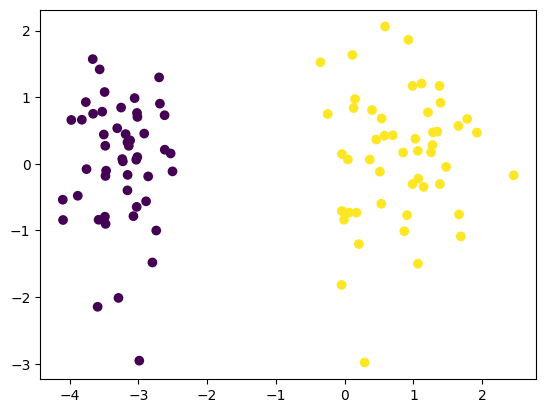

In [164]:
import matplotlib.pyplot as plt
plt.figure()
plt.scatter(x[:,0] , x[:,1],c=y)

In [165]:
def zero_or_one(z):
    return 1 if z> 0 else 0

In [166]:
def perceptron_trick(x, y ,learning_rate=0.1):
    x=np.insert(x,0,1 ,axis=1)
    weights=np.ones(x.shape[1])

    for i in range(1000):
        j=np.random.randint(0, x.shape[0])
        y_pred=zero_or_one(np.dot(x[j],weights))
        weights=weights + learning_rate* (y[j]-y_pred)*x[j]

    return weights[0] , weights[1:]

In [167]:
x.shape[0]

100

In [168]:
w0 , w1 =perceptron_trick(x,y)
w1   #here w0= intercept and w1= weights or coffocients

array([1.05343617, 0.2221512 ])

In [169]:
#equation Ax + Bx + C -----> y= mx+c
m=-(w1[0]/w1[1])
c=-w0/w1[1]

In [170]:
x_inp=np.linspace(-3 , 3 , 100)
y_inp=m*x_inp + c 

Text(0.5, 0, 'y')

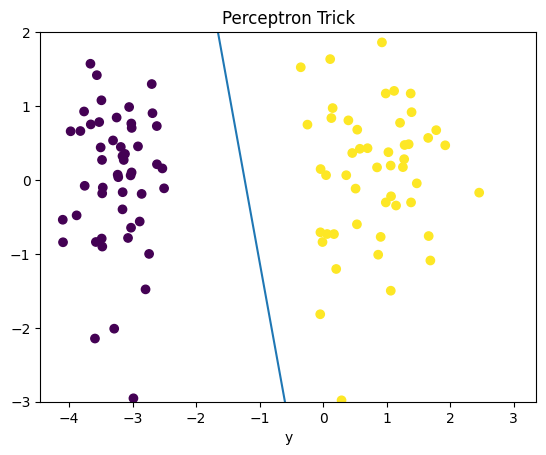

In [171]:
plt.plot(x_inp, y_inp)
plt.scatter(x[:,0] , x[:,1],c=y)
plt.ylim(-3,2)
plt.title("Perceptron Trick")
plt.xlabel("X")
plt.xlabel("y")

### real Logistic Regression

In [172]:
from sklearn.linear_model import LogisticRegression
lr= LogisticRegression()
lr.fit(x,y)

LogisticRegression()

In [173]:
model_c=lr.intercept_
model_coff=lr.coef_
model_m=-model_coff[0][0]/model_coff[0][1]
model_c=-model_c[0]/model_coff[0][1]
model_coff

array([[2.36679363, 0.02300492]])

In [174]:
x_model=np.linspace(-3,3,100)
y_model=model_m *x_model + model_c

### Difference between model and perceptrom trick

Text(0.5, 0, 'y')

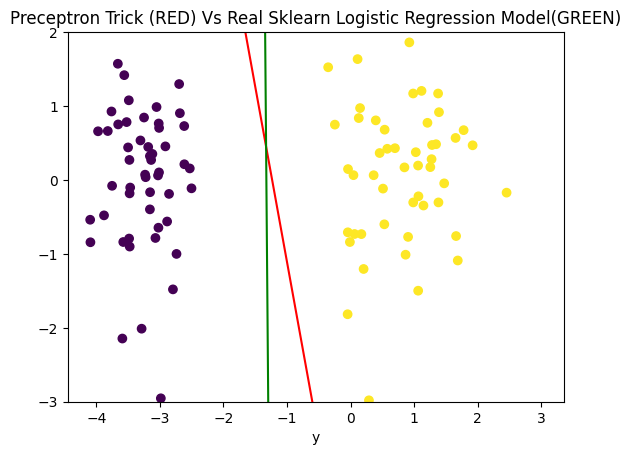

In [175]:
plt.plot(x_inp, y_inp , color="red")
plt.plot(x_model, y_model , color="green")
plt.scatter(x[:,0] , x[:,1],c=y)
plt.ylim(-3,2)
plt.title("Preceptron Trick (RED) Vs Real Sklearn Logistic Regression Model(GREEN)")
plt.xlabel("X")
plt.xlabel("y")

### Major Problem with Preceptron trick and Solve

In [176]:
def perceptron_trick_with_sigmoid(x, y ,learning_rate=0.1):
    x=np.insert(x,0,1 ,axis=1)
    weights=np.ones(x.shape[1])

    for i in range(1000):
        j=np.random.randint(0, x.shape[0])
        y_pred=sigmoid(np.dot(x[j],weights))
        weights=weights + learning_rate* (y[j]-y_pred)*x[j]

    return weights[0] , weights[1:]

In [177]:
def sigmoid(x):
    return 1/(1+ np.exp(-x))

Text(0.5, 0, 'y')

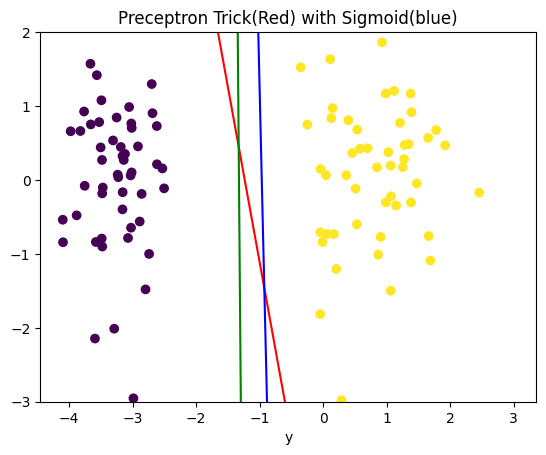

In [178]:
plt.plot(x_inp, y_inp , color="red")
intercept , coff =perceptron_trick_with_sigmoid(x,y)
m=-(coff[0]/coff[1])
c=-intercept/coff[1]
x_sogmoid=np.linspace(-3 , 3 , 100)
y_sigmoid=m*x_sogmoid + c  
plt.plot(x_sogmoid, y_sigmoid , color="blue")
plt.plot(x_model, y_model , color="green")
plt.scatter(x[:,0] , x[:,1],c=y)
plt.ylim(-3,2)
plt.title("Preceptron Trick(Red) with Sigmoid(blue)")
plt.xlabel("X")
plt.xlabel("y")

### Final Solution using MaximumLikelyHood

In [179]:
def Maximumlikelyhood(x,y , learning_rate=0.1):
    x=np.insert(x, 0, 1 , axis=1)
    coff = np.zeros(x.shape[1])

    for i in range(30000):
        y_pred=sigmoid(np.dot(x,coff))   #use all (batch) so this is batch Gradient descent
        coff += (learning_rate/x.shape[0])* np.dot((y - y_pred) , x)

    return coff[0] , coff[1:]

In [180]:
intercept , coff =Maximumlikelyhood(x,y)
m=-(coff[0]/coff[1])
c=-intercept/coff[1]
x_sogmoid=np.linspace(-3 , 3 , 100)
y_sigmoid=m*x_sogmoid + c 
print(intercept , coff)

6.011779733098619 [4.96399232 0.22269684]


In [181]:
from sklearn.linear_model import LogisticRegression
lr= LogisticRegression(penalty=None , solver="sag")
lr.fit(x,y)
model_c=lr.intercept_
model_coff=lr.coef_
model_m = -(model_coff[0][0] / model_coff[0][1])
model_c = -(model_c[0] / model_coff[0][1])
model_coff
x_model=np.linspace(-3,3,100)
y_model=model_m *x_model + model_c

C:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Text(0.5, 0, 'y')

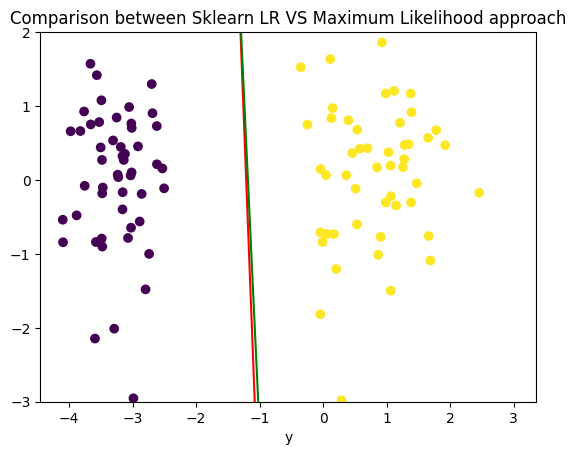

In [182]:
# plt.plot(x_inp, y_inp) 
plt.plot(x_sogmoid, y_sigmoid , color="red")
plt.plot(x_model, y_model , color="green")
plt.scatter(x[:,0] , x[:,1],c=y)
plt.ylim(-3,2)
plt.title("Comparison between Sklearn LR VS Maximum Likelihood approach")
plt.xlabel("X")
plt.xlabel("y")

In [183]:
print(intercept, coff)
print(lr.intercept_, lr.coef_)

6.011779733098619 [4.96399232 0.22269684]
[5.95303494] [[5.02751439 0.27203855]]
